# 🧪 01 - Exploratory Data Analysis (EDA)
This notebook explores the UCI Diabetes 130-Hospitals dataset to understand the features,
target distribution, and potential issues like missing data or class imbalance.

**Goals:**
- Understand the structure of the data
- Identify missing or problematic values
- Explore relationships between features and readmission status

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load original CSV
df = pd.read_csv("../data/diabetic_data.csv")

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
# Missing values
print("\nMissing values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate rows:")
print(df.duplicated().sum())


Missing values:
encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                    

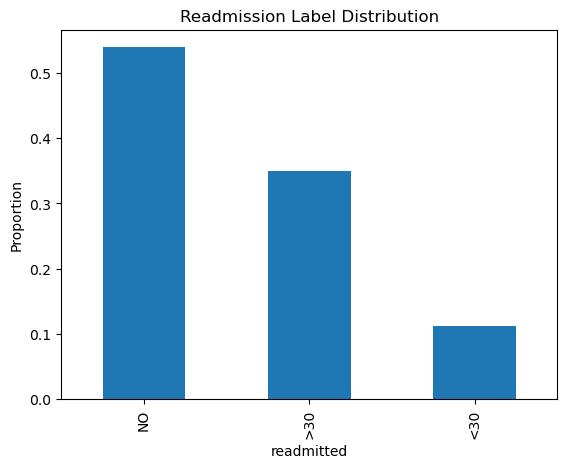

In [5]:
# Examine original readmitted label
df['readmitted'].value_counts(normalize=True).plot(kind='bar', title='Readmission Label Distribution')
plt.ylabel("Proportion")
plt.show()

### Readmission Label Distribution

The target variable `readmitted` originally has three values:

- `NO` — No readmission (≈ 54%)
- `>30` — Readmitted after 30 days (≈ 35%)
- `<30` — Readmitted within 30 days (≈ 11%)

This shows a clear class imbalance, with far fewer early readmissions — which is often the class of most clinical interest.


In [6]:
for col in ['gender', 'race', 'age']:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


gender value counts:
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

race value counts:
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

age value counts:
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64


### Categorical Feature Distributions

- **Gender**
  - Female: 54.7%
  - Male: 47.0%
  - Unknown/Invalid: <0.01% → will be handled in preprocessing.

- **Race**
  - Caucasian and AfricanAmerican make up ~95% of the population.
  - "?" appears as missing and will be imputed or dropped.

- **Age**
  - Heavily skewed toward older adults (60+):
    - [70–80): 26%
    - [60–70): 22%
    - [80–90): 17%
  - Children and young adults are very rare in this dataset.


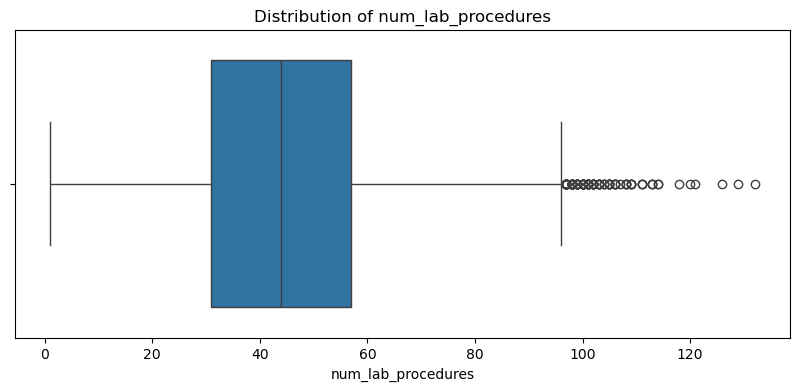

In [7]:
df.describe()

# Boxplots for continuous vars (optional)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['num_lab_procedures'])
plt.title("Distribution of num_lab_procedures")
plt.show()


### Outlier Detection: `num_lab_procedures`

- The boxplot shows several high-end outliers.
- Most patients had between 30–90 lab procedures.
- Extreme values >100 exist but represent a small fraction.
- These will be clipped using the IQR method in preprocessing.
